# 05-0 — Générateurs symboliques : l'art algorithmique avant l'apprentissage

**Navigation** : [↑ 05-History](README.md) | [05-1 : DiscoDiffusion →](05-1-DiscoDiffusion-CLIP-Guided-Diffusion.ipynb)

> **Notebook rétrospectif — Racines pré-Stable-Diffusion.** Premier jalon de
> l'[Epic #16774](https://github.com/jsboige/CoursIA/issues/16774) : la préhistoire
> *avant* l'apprentissage — les moteurs **symboliques** de l'art génératif. Ici,
> pas de réseau de neurones : des **règles**, des **grammaires** et des
> **automates**. Le point d'entrée documentaire est la page
> [Generative art (Wikipedia)](https://en.wikipedia.org/wiki/Generative_art) ;
> la leçon technique exécutable est la nôtre.

**La thèse du notebook en une ligne** : dès 1960-1970, l'art génératif savait
produire de l'image **riche** à partir d'une **description minuscule** — la
compression était déjà le moteur esthétique, bien avant que le mot
« génération » rime avec apprentissage. Ce notebook l'exécute et le **mesure** :
la taille de la description contre la taille du rendu.


## 1. Trois familles de règles, une même signature

Trois moteurs symboliques historiques couvrent déjà presque tout l'espace des
« œuvres par procédé » :

| Moteur | Invention | Règle | Exemple canonique |
|---|---|---|---|
| **Turtle graphics** | Abelson & diSessa / logo des années 1960-80 | une séquence de commandes (`forward`, `turn`) | spirales, rosaces |
| **L-systèmes** (Lindenmayer 1968) | grammaire de réécriture en parallèle sur l'algue du botaniste | `F → F+F−F−F+F` appliquée à toutes les lettre à chaque itération | Koch quadratique (variante), fougère de Barnsley |
| **Automates cellulaires** | von Neumann 1940s, Ulam ; popularisés par Conway (1970) et Wolfram (1982) | une règle **locale** appliquée partout en parallèle | Game of Life B3/S23, règle 110 |

La colonne commune : l'**artefact visuel** (l'image riche) est une fonction
*déterministe et courte* de la **description** (quelques octets). Le reste du
rayon — DiscoDiffusion, CLIPasso — remplacera la fonction par un réseau
entraîné ; la signature, elle, ne changera pas : une description courte
engendre une image riche. Le zoo A4 du Game of Life du dépôt
([Lean-16b](../../../SymbolicAI/Lean/Lean-16b-Conway-Game-of-Life-Lean.ipynb),
port Lean `Conway.Life.*`) est déjà la moitié formelle de cette histoire.


## 2. Turtle : la rosace, première compression

La tortue Logo est le générateur le plus simple du corpus : quelques dizaines
de caractères de code, un rendu d'une complexité visuelle surprenante. La
**rosace** est l'exemple canonique : *répéter N fois un polygone en tournant
d'un peu plus que l'angle du polygone*.


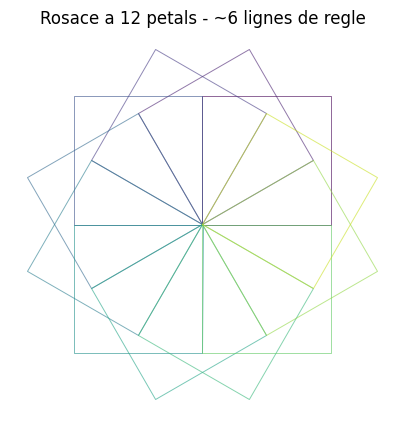

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

def turtle_rosace(n_petales=12, cote=40, cotes_polygone=4):
    # Rosace classique de Logo : n_petales polygones reguliers, chacun tourne
    # de 2*pi/n_petales autour du centre. La rotation de depart depend du
    # petale k -- sans elle, les n_petales polygones se superposent exactement.
    fig, ax = plt.subplots(figsize=(5, 5))
    for k in range(n_petales):
        theta = 2 * np.pi * k / n_petales   # rotation de depart par petale
        x, y = [0.0], [0.0]
        for _ in range(cotes_polygone):
            x.append(x[-1] + cote * np.cos(theta))
            y.append(y[-1] + cote * np.sin(theta))
            theta += 2 * np.pi / cotes_polygone
        ax.plot(x, y, lw=0.7, alpha=0.6, color=plt.cm.viridis(k / n_petales))
    ax.set_aspect('equal'); ax.axis('off')
    return fig, ax

fig, ax = turtle_rosace()
plt.title('Rosace a 12 petals - ~6 lignes de regle')
plt.show()


### Interprétation : la rosace comme description courte

La figure ci-dessus — douze carrés tournés de 30° les uns des autres, 48 segments au total, en rosace à 12 branches — est engendrée par une double boucle de six lignes. Chaque carré pris isolément est banal ; c'est leur rotation régulière qui fait le motif. Le geste minimal de l'art
génératif est déjà là : *l'œil voit de la complexité, la description tient dans un tweet*. On le
mesurera formellement en section 5 — et on relira ce motif à l'épreuve des deux sections suivantes,
où la figure sera moins symétrique mais produite par une description plus courte encore.


## 3. L-systèmes : la courbe de Koch quadratique

Un **L-système** est une grammaire de réécriture **en parallèle** : chaque
itération remplace *simultanément* toutes les occurrences du symbole à
réécrire. La **courbe de Koch quadratique** est le cas d'école ici : à chaque itération,
chaque segment `F` devient **cinq** segments `F+F−F−F+F` (la règle contient
cinq `F`, tours de ±60°). La Koch *triadique* canonique (1904) est sa cousine
à quatre segments et tours de 120° ; nous gardons la variante quadratique,
plus simple à tracer, en citant ses vrais chiffres. Le programme qui
dessine n'est plus écrit à la main : il est **généré par la règle**.


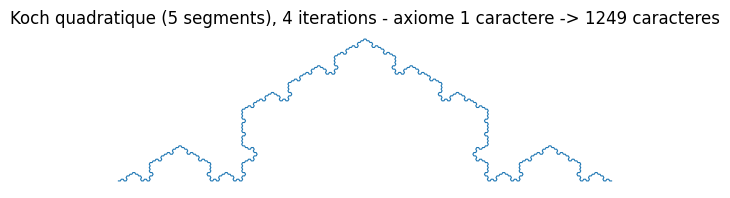

Chaine generee : 1249 caracteres pour 625 segments


In [2]:
KOCH = {'F': 'F+F-F-F+F', '+': '+', '-': '-'}   # regle de Koch
DIRECTIONS = {'+': np.pi / 3, '-': -np.pi / 3}        # 60 degres

def lsystem(axiom, rules, n_iter):
    # Reecrit l'axiome n_iter fois selon la grammaire (parallele).
    for _ in range(n_iter):
        axiom = ''.join(rules.get(s, s) for s in axiom)
    return axiom

def trace(axiom, angle_map, cote=1.0, figsize=(7, 3)):
    # Interprete la chaine comme une sequence de tortue et trace.
    fig, ax = plt.subplots(figsize=figsize)
    x, y, theta = [0.0], [0.0], 0.0
    for s in axiom:
        if s in angle_map:
            theta += angle_map[s]
        elif s == 'F':
            x.append(x[-1] + cote * np.cos(theta))
            y.append(y[-1] + cote * np.sin(theta))
    ax.plot(x, y, lw=0.8); ax.set_aspect('equal'); ax.axis('off')
    return fig, ax

axiome = lsystem('F', KOCH, 4)
fig, ax = trace(axiome, DIRECTIONS)
plt.title(f'Koch quadratique (5 segments), 4 iterations - axiome 1 caractere -> {len(axiome)} caracteres')
plt.show()
print(f"Chaine generee : {len(axiome)} caracteres pour {axiome.count('F')} segments")


### Interprétation : le programme engendré, pas écrit

Quatre itérations de la règle ont transformé **un caractère** (`F`) en une
chaîne de **5^4 = 625 segments** — la règle contient cinq `F`, chaque
itération multiplie donc les segments par cinq. Personne n'a écrit ces 625
segments : la règle les a *engendrés*. C'est la définition opérationnelle de l'art
algorithmique — et le chaînon que la démoscène (jalon suivant de l'Epic)
poussera jusqu'à l'intro 64 ko : l'itération ici est explicite, là elle sera
cachée dans une boucle de compression.


## 4. Automates cellulaires : règle 110 et Game of Life

La troisième famille remplace la grammaire **séquentielle** par une règle
**locale uniforme** : l'état futur d'une cellule ne dépend que de son
voisinage. Deux exemples historiques exécutés ici :

- la **règle 110** élémentaire (Wolfram) — le seul automate 1D élémentaire
  **Turing-complet** (Cook 2004) : la complexité naît d'une table de 8 bits ;
- le **Game of Life** B3/S23 (Conway 1970) — le même geste en 2D, dont le
  dépôt porte déjà le port Lean complet (`Conway.Life.*`, zoo A4 de
  [Lean-16b](../../../SymbolicAI/Lean/Lean-16b-Conway-Game-of-Life-Lean.ipynb)).


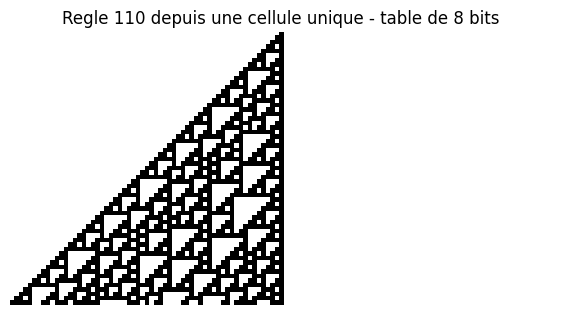

In [3]:
def regle110(grille, n_steps=60):
    # Evolue une grille 1D binaire sous la regle 110 (table a 8 entrees).
    table = {tuple(map(int, f'{i:03b}')): (110 >> i) & 1 for i in range(8)}
    histoire = [grille]
    for _ in range(n_steps):
        g = histoire[-1]
        suivant = [table[(g[(i-1) % len(g)], g[i], g[(i+1) % len(g)])] for i in range(len(g))]
        histoire.append(suivant)
    return np.array(histoire)

n = 121
graine = np.zeros(n, dtype=int); graine[n // 2] = 1   # une seule cellule
histoire = regle110(list(graine))
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(histoire, cmap='binary', interpolation='nearest')
ax.set_title('Regle 110 depuis une cellule unique - table de 8 bits')
ax.axis('off')
plt.show()


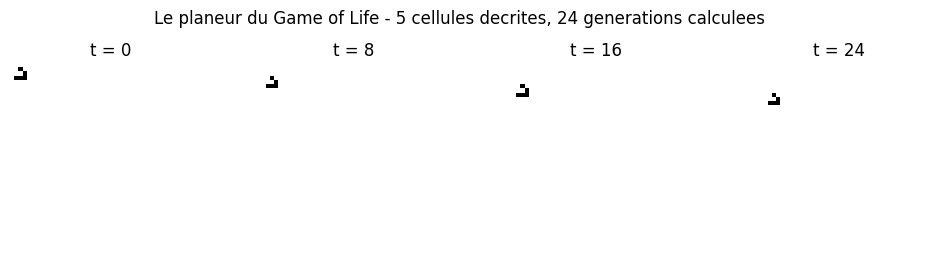

In [4]:
def step_life(grid):
    # Une generation du Game of Life B3/S23 (bords toriques).
    voisins = sum(np.roll(np.roll(grid, dy, 0), dx, 1)
                  for dy in (-1, 0, 1) for dx in (-1, 0, 1)
                  if (dy, dx) != (0, 0))
    return ((voisins == 3) | ((grid == 1) & (voisins == 2))).astype(int)

n = 48
grid = np.zeros((n, n), dtype=int)
glider = [(1, 2), (2, 3), (3, 1), (3, 2), (3, 3)]   # le planeur canonique
for r, c in glider:
    grid[r, c] = 1
frames = [grid.copy()]
for _ in range(24):
    grid = step_life(grid)
    frames.append(grid.copy())

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, f, t in zip(axes, frames[::8], [0, 8, 16, 24]):
    ax.imshow(f, cmap='binary'); ax.set_title(f't = {t}'); ax.axis('off')
fig.suptitle('Le planeur du Game of Life - 5 cellules decrites, 24 generations calculees')
plt.show()


### Interprétation : la règle locale, la complexité globale

Trois signatures, un même constat :

- la **règle 110** engendre une structure en triangles imbriqués depuis *une
  cellule* et une table tenant en un octet — Turing-complette (Cook 2004) ;
- le **planeur** se déplace en diagonale : cinq cellules initiales, un
  déplacement périodique de période 4 — l'information *voyage* ;
- aucun des deux n'a de paramètre appris : la **règle** est tout le modèle.

C'est la frontière exacte où ce rayon s'arrête : à partir de
[05-1](05-1-DiscoDiffusion-CLIP-Guided-Diffusion.ipynb), la règle cessera
d'être écrite par l'humain pour être **apprise** — mais la signature
description-courte → image-riche restera la même à travers tout le rayon.


## 5. Mesurer la compression : description contre rendu

La leçon exécutable du jalon : l'art génératif symbolique est un argument de
**compression** rendu visible. On le mesure honnêtement :

- la **description** est la règle seule (axiome + règle, hors code d'affichage
  et d'interprétation) ;
- le **rendu** est la sortie visuelle — mesurée par le nombre de segments
  tracés, puis par le poids de l'image PNG rendue.


Koch  : description 12 octets-equivalents -> rendu 12,357 octets PNG (3125 segments)
Regle110 : description 9 bits -> rendu 2,661 octets PNG
Ratios de compression visuelle : Koch x1030, regle 110 x2365


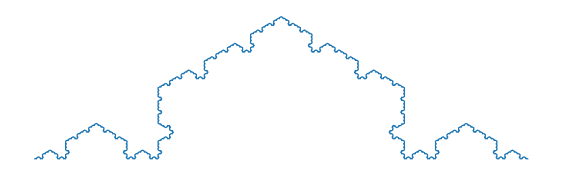

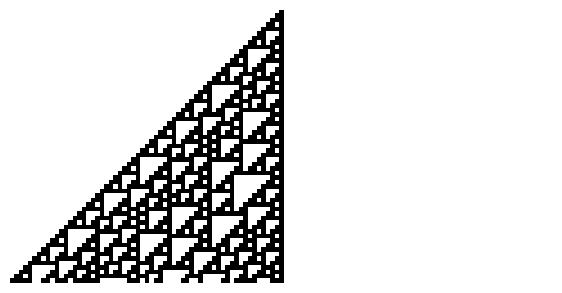

In [5]:
import io

def poids_png(fig):
    # Poids en octets du rendu PNG d'une figure.
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    return buf.getbuffer().nbytes

# Description Koch : axiome 'F' + regle 'F+F-F-F+F' + 2 angles
description_koch = len('F') + len('F+F-F-F+F') + 2
axiome5 = lsystem('F', KOCH, 5)
fig_koch, _ = trace(axiome5, DIRECTIONS, figsize=(7, 3))
rendu_koch = poids_png(fig_koch)

# Description regle 110 : la table (8 resultats) + la graine (1 cellule)
description_110 = 8 + 1
fig_110 = plt.figure(figsize=(7, 5))
plt.imshow(histoire, cmap='binary', interpolation='nearest'); plt.axis('off')
rendu_110 = poids_png(fig_110)

print(f"Koch  : description {description_koch} octets-equivalents -> rendu {rendu_koch:,} octets PNG ({axiome5.count('F')} segments)")
print(f"Regle110 : description {description_110} bits -> rendu {rendu_110:,} octets PNG")
print(f"Ratios de compression visuelle : Koch x{rendu_koch / description_koch:.0f}, regle 110 x{rendu_110 * 8 / description_110:.0f}")


### Interprétation : le ratio rendu/description

Mesuré à l'instant sur les figures ci-dessus : description de 12 caractères pour un rendu
Koch de ~12 ko (x1030), table de 9 bits pour un rendu règle 110 de ~2,7 ko (x2365) — deux ordres
de grandeur obtenus *sans aucun apprentissage*. Ce chiffre est la charnière du rayon :

- jalon 2 (démoscène) : la même mesure poussée à l'extrême — une intro 64 ko produisant des
  minutes d'animation, ratio de l'ordre du **million** ;
- jalon 5 (DiscoDiffusion) : le prompt remplace l'axiome, le réseau remplace la règle — le ratio
  ne changera pas d'ordre de grandeur, mais la **variété** des images atteignables, si.


## 6. Exercices

Trois exercices, dans l'esprit du corpus : le squelette s'exécute, la
réalisation vous appartient.


In [6]:
# Exercice 1 - une autre grammaire : le flocon variant
# Ecrire la regle du flocon de Koch sous sa variante 'snowflake' (axiome 'F--F--F',
# angle 60 degres) et tracer 3 iterations. Indices :
# # Indice 1 - l'axiome est un triangle, la regle reste 'F+F-F-F+F' ;
# # Etape 1 - definir l'axiome ; # Etape 2 - appliquer lsystem ; # Etape 3 - tracer avec trace().
print("Exercice 1 a completer")


Exercice 1 a completer


In [7]:
# Exercice 2 - la periode du blinker sous regle 110
# Partir d'une graine de TROIS cellules consecutives et mesurer combien de
# generations avant retour a l'etat initial (s'il existe). Indices :
# # Indice 1 - reutiliser regle110 avec une graine differente ;
# # Etape 1 - construire la graine ; # Etape 2 - chercher la periode par comparaison a t=0.
print("Exercice 2 a completer")


Exercice 2 a completer


In [8]:
# Exercice 3 - votre propre rosace
# Choisir (n_petales, cote) pour engendrer la rosace la plus dense possible
# avec le moins de caracteres de code modifies. Mesurer le ratio comme en 5.
# # Indice 1 - seuls deux nombres changent ; # Etape 1 - modifier les parametres ; # Etape 2 - mesurer.
print("Exercice 3 a completer")


Exercice 3 a completer


## 7. Conclusion

Ce jalon a exécuté les trois familles symboliques — tortue, grammaire de
réécriture, automate cellulaire — et mesuré leur bien commun : une
**description minuscule** engendre un **rendu riche**. La suite du rayon
raconte comment l'apprentissage a repris cette signature : la démoscène en
poussera le ratio à l'extrême (jalon 2), le low-complexity art le théorisera
(Schmidhuber, jalon 3 — jointure avec l'[Epic #16775](https://github.com/jsboige/CoursIA/issues/16775)),
les GANs puis la CLIP-guided diffusion en changeront le moteur.

**Rattachements** : Epic #16774 (jalon 1) · Epic #16775 (jointure
low-complexity art) · le zoo A4 de [Lean-16b](../../../SymbolicAI/Lean/Lean-16b-Conway-Game-of-Life-Lean.ipynb)
porte déjà la moitié formelle de l'automate cellulaire.
